# Wildfire Fuel Risk Scoring
A terrain-based quantitative risk-scoring prototype using the sklearn covtype dataset (Roosevelt National Forest, CO).

## 1. Data Loading & Setup
Load the forest cover dataset and build a labeled DataFrame with readable terrain feature names.

In [ ]:
import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

X, y = skl.datasets.fetch_covtype(random_state=440, shuffle=True, return_X_y=True)

features = (
    ['Elevation', 'Aspect', 'Slope',
     'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology','Horizontal_Distance_To_Roadways',
     'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
     'Horizontal_Distance_To_Fire_Points']
    + [f'Wilderness_Area_{i+1}' for i in range(4)]
    + [f'Soil_Type_{i+1}' for i in range(40)]
)

df = pd.DataFrame(X, columns=features)
df['Cover_Type'] = y
print(df.shape)
df.head()

(581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,3281.0,291.0,32.0,234.0,17.0,3371.0,115.0,216.0,232.0,1839.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
1,2746.0,324.0,4.0,362.0,15.0,1006.0,209.0,235.0,165.0,1857.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,3203.0,295.0,12.0,30.0,0.0,4744.0,187.0,237.0,190.0,466.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,2295.0,119.0,20.0,30.0,8.0,492.0,250.0,218.0,87.0,794.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,3291.0,222.0,6.0,524.0,96.0,5190.0,213.0,245.0,169.0,1022.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


## 2. Risk Score Construction
Assign a species-level baseline fuel score, then adjust it using terrain factors known to affect real fire behavior (solar exposure, slope, proximity to historical fire activity). Combine into a single 1–10 `Risk_Scor`.

In [ ]:
cover_types = {
    1: 'Spruce/Fir', 2: 'Lodgepole Pine', 3: 'Ponderosa Pine', 4: 'Cottonwood/Willow', 5: 'Aspen', 6: 'Douglas-fir', 7: 'Krummholz'
}
df['Cover_Type_Name'] = df['Cover_Type'].map(cover_types)

fuel_score = {
    1: 8.0,  # Spruce/Fir - dense, resinous, high crown-fire potential
    2: 8.5,  # Lodgepole Pine - highly flammable, serotinous cones adapted to stand-replacing fire
    3: 6.5,  # Ponderosa Pine - resinous, but historically adapted to frequent low-intensity fire (thicker bark)
    4: 2.0,  # Cottonwood/Willow - riparian, moist, low resin
    5: 1.5,  # Aspen - high moisture content, natural firebreak
    6: 9.0,  # Douglas-fir - very resinous, common in high-severity fire regimes
    7: 4.0,  # Krummholz - conifer, but sparse/stunted growth reduces fuel continuity
}
df['Base_Fuel_Score'] = df['Cover_Type'].map(fuel_score)

def solar_factor(aspect_deg):
  diff = np.abs(aspect_deg - 180)
  diff = np.minimum(diff, 360 - diff)
  return 1 - (diff / 180)

df['Solar_Exposure'] = solar_factor(df['Aspect'])
df['Slope_Norm'] = (df['Slope'] - df['Slope'].min()) / (df['Slope'].max() - df['Slope'].min())
df['Fire_Proximity_Norm'] = 1 - ((df['Horizontal_Distance_To_Fire_Points'] - df['Horizontal_Distance_To_Fire_Points'].min()) / (df['Horizontal_Distance_To_Fire_Points'].max() - df['Horizontal_Distance_To_Fire_Points'].min()))

terrain_adjustment = (2.0 * df['Solar_Exposure'] + 1.5 * df['Slope_Norm'] + 1.5 * df['Fire_Proximity_Norm'])
raw_score = df['Base_Fuel_Score'] + terrain_adjustment
df['Risk_Score'] = (1 + 9 * (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min())).round(1)

df.groupby('Cover_Type_Name')['Risk_Score'].describe()

,count,mean,std,min,25%,50%,75%,max
Cover_Type_Name,,,,,,,,
Aspen,9493.0,2.811082,0.493209,1.0,2.5,2.8,3.2,3.9
Cottonwood/Willow,2747.0,3.386968,0.496042,2.1,3.0,3.5,3.8,4.5
Douglas-fir,17367.0,8.509121,0.377124,7.5,8.2,8.5,8.7,10.0
Krummholz,20510.0,4.555041,0.551331,3.3,4.1,4.5,5.0,6.1
Lodgepole Pine,283301.0,8.085078,0.543099,6.4,7.7,8.1,8.5,9.7
Ponderosa Pine,35754.0,6.889775,0.462185,5.6,6.5,6.9,7.3,8.1
Spruce/Fir,211840.0,7.624590,0.490727,6.0,7.3,7.6,8.0,9.1


### Baseline Fuel Risk by Species
A quick check that the assigned baseline scores look reasonable independent of terrain.

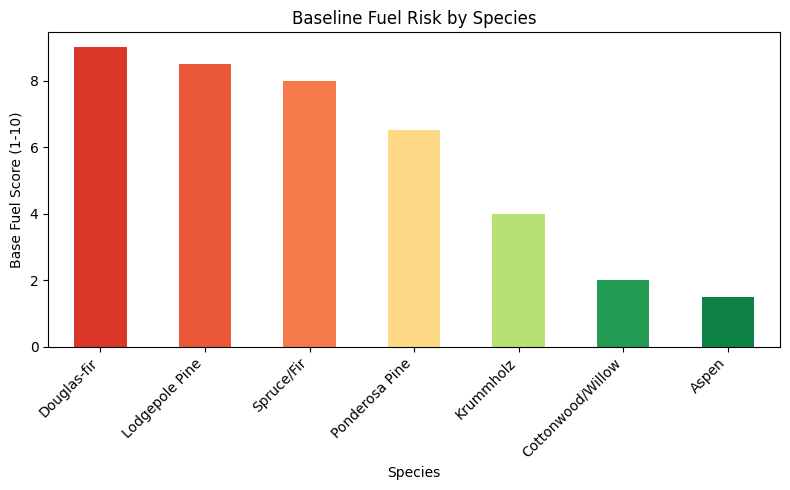

In [ ]:
fuel_by_species = df.groupby('Cover_Type_Name')['Base_Fuel_Score'].first().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colors = plt.cm.RdYlGn_r((fuel_by_species.values - 1) / 9)  # scale color to the 1-10 range
fuel_by_species.plot(kind='bar', color=colors)
plt.ylabel('Base Fuel Score (1-10)')
plt.xlabel('Species')
plt.title('Baseline Fuel Risk by Species')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Model Training
Train a Random Forest regressor to predict `Risk_Score` from terrain and soil features alone — species identity, and every column used to construct the score, are deliberately excluded so the model has to infer risk from indirect proxies.

In [ ]:
model_features = [i for i in df.columns if i not in ['Cover_Type', 'Cover_Type_Name', 'Base_Fuel_Score', 'Solar_Exposure', 'Slope_Norm', 'Fire_Proximity_Norm', 'Risk_Score']]

X_reg, y_reg = df[model_features], df['Risk_Score']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=440)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=440, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)

y_pred_r = rf_reg.predict(X_test_r)
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("R²:", r2_score(y_test_r, y_pred_r))

MAE: 0.14445910174436125
R²: 0.8590380304088182


### Validation: Predicted vs. Actual

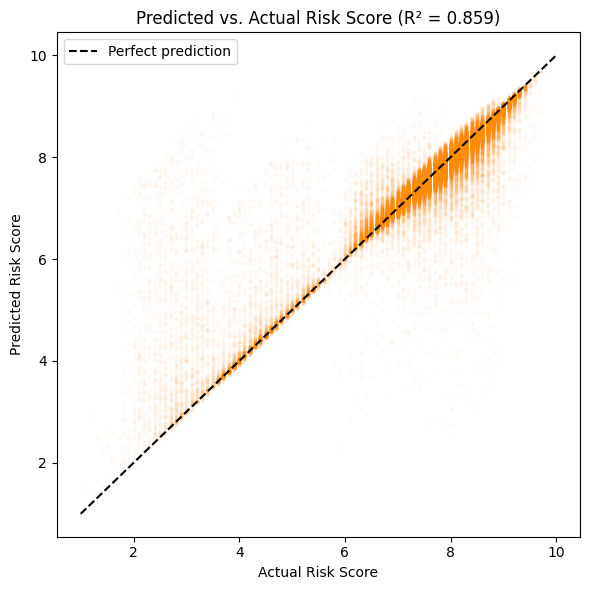

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.02, s=5, color='darkorange')
plt.plot([1, 10], [1, 10], 'k--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Risk Score')
plt.ylabel('Predicted Risk Score')
plt.title(f'Predicted vs. Actual Risk Score (R² = {r2_score(y_test_r, y_pred_r):.3f})')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Feature Importance
Which terrain/soil signals is the model actually relying on to approximate risk?

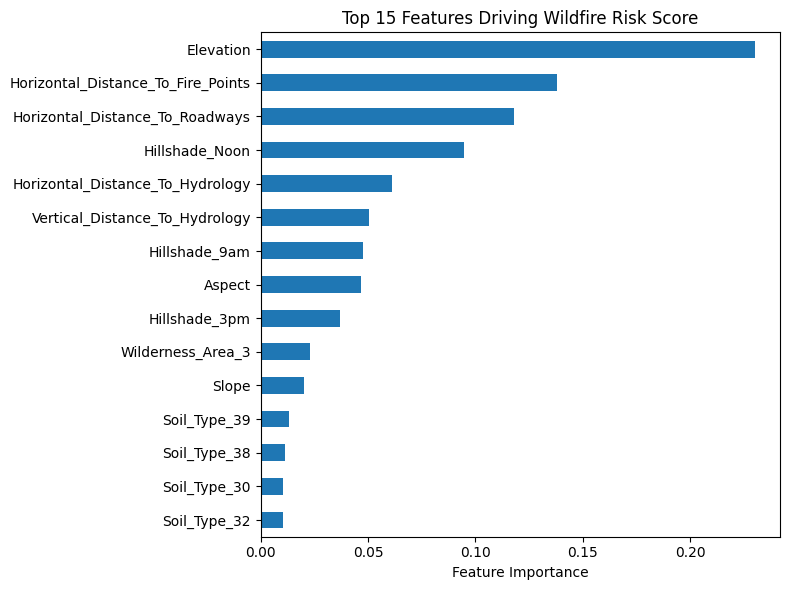

,0
Elevation,0.230353
Horizontal_Distance_To_Fire_Points,0.137968
Horizontal_Distance_To_Roadways,0.118102
Hillshade_Noon,0.094553
Horizontal_Distance_To_Hydrology,0.061006
Vertical_Distance_To_Hydrology,0.050252
Hillshade_9am,0.047620
Aspect,0.046619
Hillshade_3pm,0.036942
Wilderness_Area_3,0.022731


In [ ]:
most_important_feats = pd.Series(rf_reg.feature_importances_, index=model_features).sort_values(ascending=False)
top15 = most_important_feats.head(15)

plt.figure(figsize=(8, 6))
top15[::-1].plot(kind='barh')
plt.title('Top 15 Features Driving Wildfire Risk Score')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

top15

## 5. Residual Analysis
Check the model's errors for systematic bias, and see how prediction precision varies across the risk-score range.

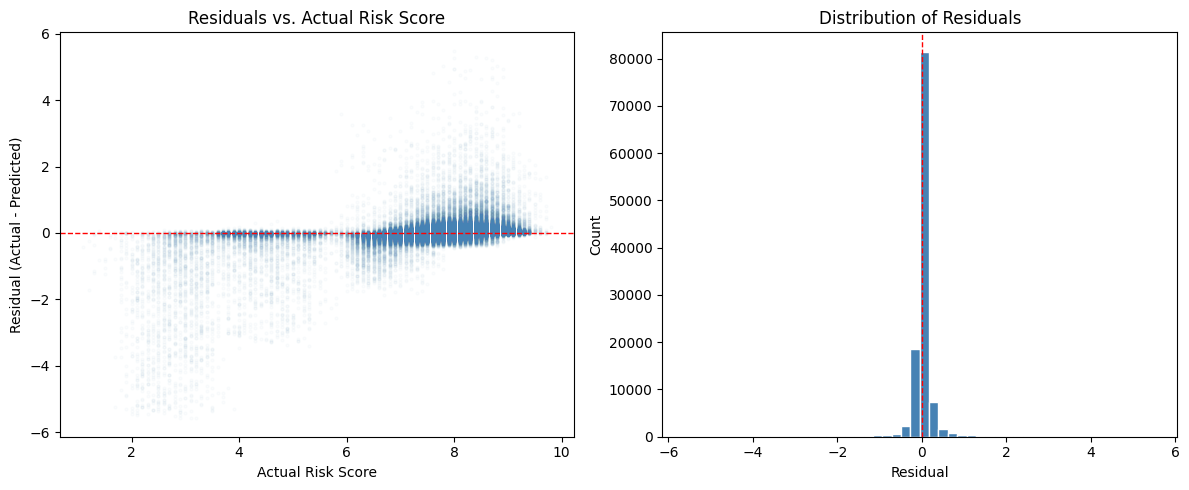

Mean residual: -0.0009515589098388411
Std residual: 0.41439865661405706


In [ ]:
residuals = y_test_r - y_pred_r

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_r, residuals, alpha=0.02, s=5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Actual Risk Score')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs. Actual Risk Score')

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Mean residual:", residuals.mean())
print("Std residual:", residuals.std())

## 6. Geographic Risk Pattern
Aggregate Risk_Score across elevation and aspect bins to look for a spatial pattern — since the dataset has no true lat/long, this grid uses two real, fire-relevant terrain features as axes instead.

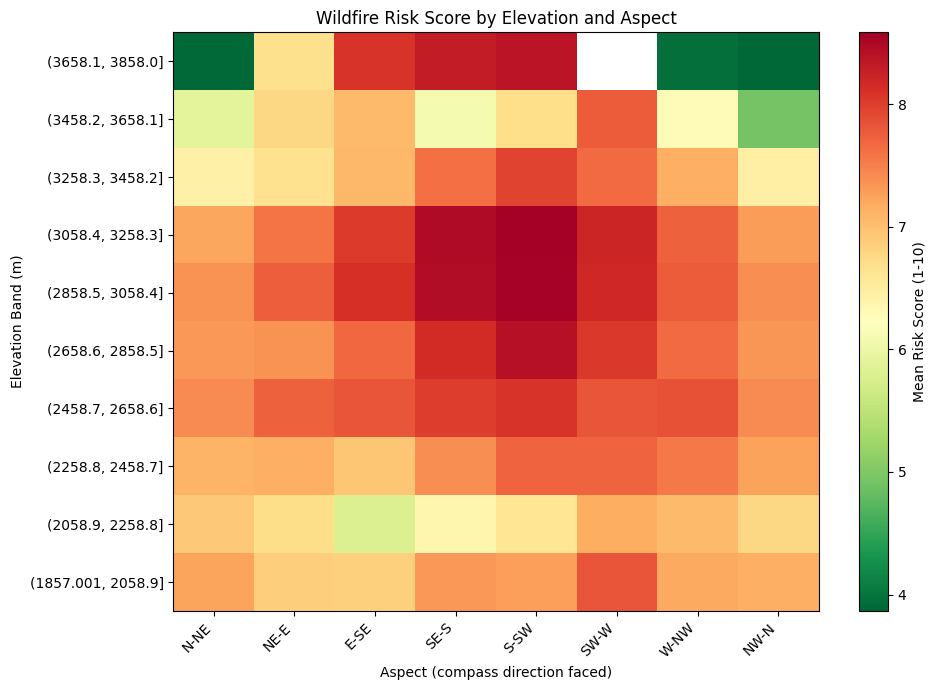

Aspect_Bin,N-NE,NE-E,E-SE,SE-S,S-SW,SW-W,W-NW,NW-N
Elevation_Bin,,,,,,,,
"(3658.1, 3858.0]",3.893818,6.682353,8.072727,8.300000,8.380000,NaN,3.948148,3.866250
"(3458.2, 3658.1]",5.911980,6.773639,7.037787,6.110795,6.696296,7.773750,6.263520,4.925917
"(3258.3, 3458.2]",6.433763,6.651531,7.064704,7.613211,7.957262,7.654597,7.146386,6.465454
"(3058.4, 3258.3]",7.206963,7.580099,8.023263,8.462722,8.585798,8.200503,7.727214,7.291806
"(2858.5, 3058.4]",7.356728,7.753635,8.121509,8.448764,8.564147,8.183305,7.759494,7.403153
"(2658.6, 2858.5]",7.324156,7.354555,7.670329,8.149949,8.416560,8.039810,7.650253,7.348485
"(2458.7, 2658.6]",7.416416,7.722902,7.822124,8.013443,8.079655,7.818439,7.847311,7.412305
"(2258.8, 2458.7]",7.102597,7.142862,6.933032,7.394363,7.715875,7.715680,7.540754,7.242077
"(2058.9, 2258.8]",6.925492,6.706265,5.817445,6.370232,6.608779,7.164506,7.053605,6.770099


In [ ]:
df['Aspect_Bin'] = pd.cut(
    df['Aspect'],
    bins=[0, 45, 90, 135, 180, 225, 270, 315, 360],
    labels=['N-NE', 'NE-E', 'E-SE', 'SE-S', 'S-SW', 'SW-W', 'W-NW', 'NW-N'],
    include_lowest=True
)

df['Elevation_Bin'] = pd.cut(df['Elevation'], bins=10)

grid = df.pivot_table(
    values='Risk_Score',
    index='Elevation_Bin',
    columns='Aspect_Bin',
    aggfunc='mean',
    observed=False
)

# order elevation bins low -> high for a readable y-axis
grid = grid.sort_index(ascending=False)

plt.figure(figsize=(10, 7))
im = plt.imshow(grid, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im, label='Mean Risk Score (1-10)')
plt.xticks(range(len(grid.columns)), grid.columns, rotation=45, ha='right')
plt.yticks(range(len(grid.index)), [str(i) for i in grid.index])
plt.xlabel('Aspect (compass direction faced)')
plt.ylabel('Elevation Band (m)')
plt.title('Wildfire Risk Score by Elevation and Aspect')
plt.tight_layout()
plt.show()

grid

### Sample Size Check
Some elevation/aspect combinations (especially at the highest elevations) have very few records — worth checking before trusting the pattern above.

In [ ]:
counts_grid = df.pivot_table(
    values='Risk_Score',
    index='Elevation_Bin',
    columns='Aspect_Bin',
    aggfunc='count',
    observed=False
).sort_index(ascending=False)

counts_grid

Aspect_Bin,N-NE,NE-E,E-SE,SE-S,S-SW,SW-W,W-NW,NW-N
Elevation_Bin,,,,,,,,
"(3658.1, 3858.0]",275,17,11,4,5,0,27,240
"(3458.2, 3658.1]",818,698,696,176,81,240,392,436
"(3258.3, 3458.2]",9617,9505,8831,7085,7092,4416,7748,8875
"(3058.4, 3258.3]",32660,28014,22164,18043,12731,12722,17403,21407
"(2858.5, 3058.4]",34394,33642,25543,15934,13126,13633,15736,23149
"(2658.6, 2858.5]",20467,21593,14253,8887,6117,4200,5737,11680
"(2458.7, 2658.6]",9637,9248,7232,4359,3942,1909,2771,5640
"(2258.8, 2458.7]",3620,3054,3203,1437,989,1537,3396,4872
"(2058.9, 2258.8]",2185,1261,1135,561,262,617,1817,2816


### Confidence-Aware Heatmap
Heatmap where cell opacity and hashing now encode sample size, so low-confidence cells (fewer than 30 records) are visually flagged rather than presented with the same weight as well-populated cells.

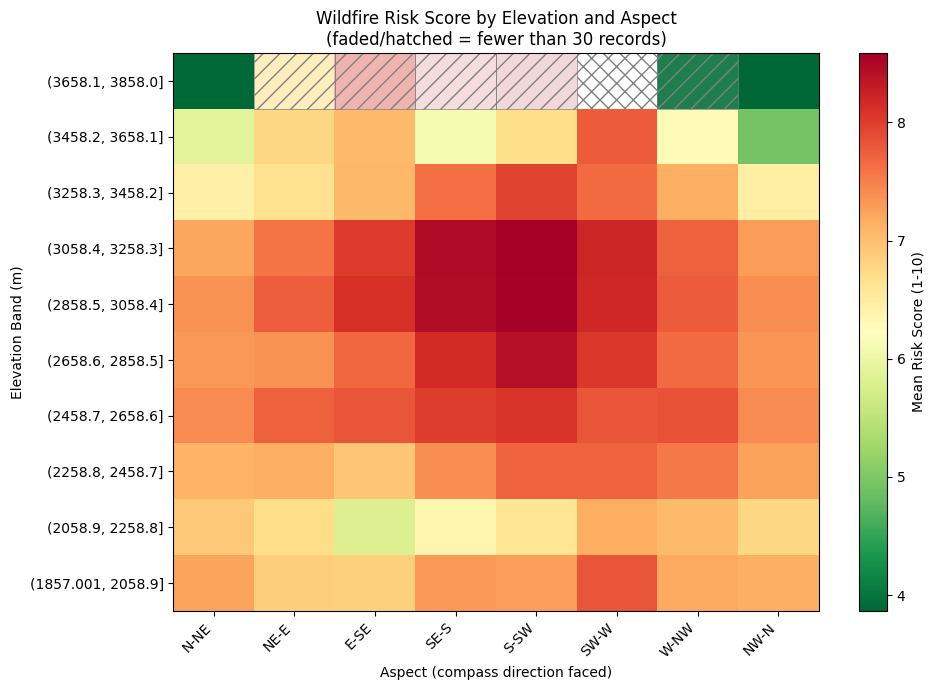

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

vmin, vmax = np.nanmin(grid.values), np.nanmax(grid.values)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('RdYlGn_r')

rgba = cmap(norm(grid.values))  # (rows, cols, 4) array

min_samples = 30  # threshold below which we treat a cell as low-confidence
confidence_alpha = np.clip(counts_grid.values / min_samples, 0.15, 1.0)  # floor so cells stay visible, don't vanish
rgba[..., 3] = confidence_alpha

nan_mask = grid.isna().values
rgba[nan_mask] = [1, 1, 1, 1]  # fully empty cells rendered white

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(rgba, aspect='auto')

low_conf_mask = counts_grid.values < min_samples
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        if nan_mask[i, j]:
            ax.add_patch(mpatches.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, hatch='xx', edgecolor='gray', linewidth=0))
        elif low_conf_mask[i, j]:
            ax.add_patch(mpatches.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, hatch='//', edgecolor='gray', linewidth=0.5))

ax.set_xticks(range(len(grid.columns)))
ax.set_xticklabels(grid.columns, rotation=45, ha='right')
ax.set_yticks(range(len(grid.index)))
ax.set_yticklabels([str(idx) for idx in grid.index])
ax.set_xlabel('Aspect (compass direction faced)')
ax.set_ylabel('Elevation Band (m)')
ax.set_title(f'Wildfire Risk Score by Elevation and Aspect\n(faded/hatched = fewer than {min_samples} records)')

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mean Risk Score (1-10)')

plt.tight_layout()
plt.savefig('confidence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. From Score to Decision
An illustrative, non-calibrated example of how a continuous risk score could translate into categorical bands for downstream decision-making.

In [ ]:
score_bands = pd.DataFrame({
    'Risk_Category': ['Low', 'Moderate', 'Elevated', 'Severe'],
    'Score_Range': ['1.0 - 3.0', '3.1 - 6.0', '6.1 - 8.5', '8.6 - 10.0'],
    'Suggested_Interpretation': [
        'Minimal terrain-driven concern',
        'Standard monitoring',
        'Warrants closer review',
        'Recommend mitigation before proceeding',
    ]
})

print(score_bands.to_string(index=False))

Risk_Category Score_Range               Suggested_Interpretation
          Low   1.0 - 3.0         Minimal terrain-driven concern
     Moderate   3.1 - 6.0                    Standard monitoring
     Elevated   6.1 - 8.5                 Warrants closer review
       Severe  8.6 - 10.0 Recommend mitigation before proceeding


## 8. Export for Tableau
Export the elevation/aspect grid data (long format works better in Tableau than a wide pivot table)

In [ ]:
tableau_export = df[['Elevation', 'Elevation_Bin', 'Aspect', 'Aspect_Bin', 'Risk_Score', 'Cover_Type_Name']].copy()
tableau_export['Elevation_Bin'] = tableau_export['Elevation_Bin'].astype(str)
tableau_export.to_csv('wildfire_risk_tableau.csv', index=False)